# Modelos de Regressão II — Do Linear Múltiplo à Regularização

Neste notebook, consolidamos os principais conceitos de regressão, construindo a intuição passo a passo:

| Etapa | O que fazemos | Por quê |
|-------|--------------|--------|
| 1 | Regressão Linear Múltipla | Baseline forte com várias variáveis |
| 2 | Polynomial Features | Capturar não-linearidades |
| 3 | Regularização (Ridge / Lasso / Elastic Net) | Controlar overfitting |
| 4 | Avaliação Final no Teste | Medir generalização do melhor modelo |

**Dataset:** *California Housing* — prever `MedHouseVal` (valor mediano das casas, em $100k).  
**Referência da aula anterior:** Regressão Linear Simples com apenas `MedInc` obteve R² ≈ 0.45 na validação.

## 0. Importações e Configurações

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carregar o Dataset e Dividir os Dados

Faremos uma **única divisão** que será reutilizada em todos os modelos, garantindo comparações justas:

- **Treino:** 60% — para ajustar os modelos  
- **Validação:** 20% — para comparar e selecionar o melhor modelo  
- **Teste:** 20% — avaliação final, tocado apenas uma vez ao final  

In [27]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"Shape do dataset: {df.shape}")
display(df.head())
display(df.describe())

Shape do dataset: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0000,6.9841,1.0238,322.0000,2.5556,37.8800,-122.2300,4.5260
1,8.3014,21.0000,6.2381,0.9719,2401.0000,2.1098,37.8600,-122.2200,3.5850
2,7.2574,52.0000,8.2881,1.0734,496.0000,2.8023,37.8500,-122.2400,3.5210
3,5.6431,52.0000,5.8174,1.0731,558.0000,2.5479,37.8500,-122.2500,3.4130
4,3.8462,52.0000,6.2819,1.0811,565.0000,2.1815,37.8500,-122.2500,3.4220


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000,20640.0000
mean,3.8707,28.6395,5.4290,1.0967,1425.4767,3.0707,35.6319,-119.5697,2.0686
std,1.8998,12.5856,2.4742,0.4739,1132.4621,10.3860,2.1360,2.0035,1.1540
min,0.4999,1.0000,0.8462,0.3333,3.0000,0.6923,32.5400,-124.3500,0.1500
25%,2.5634,18.0000,4.4407,1.0061,787.0000,2.4297,33.9300,-121.8000,1.1960
50%,3.5348,29.0000,5.2291,1.0488,1166.0000,2.8181,34.2600,-118.4900,1.7970
75%,4.7432,37.0000,6.0524,1.0995,1725.0000,3.2823,37.7100,-118.0100,2.6472
max,15.0001,52.0000,141.9091,34.0667,35682.0000,1243.3333,41.9500,-114.3100,5.0000


In [28]:
# Matriz de correlação com o target
corr = df.corr()["MedHouseVal"].sort_values(ascending=False)
print("Correlação com MedHouseVal:\n")
print(corr)

Correlação com MedHouseVal:

MedHouseVal    1.0000
MedInc         0.6881
AveRooms       0.1519
HouseAge       0.1056
AveOccup      -0.0237
Population    -0.0246
Longitude     -0.0460
AveBedrms     -0.0467
Latitude      -0.1442
Name: MedHouseVal, dtype: float64


In [29]:
# ── Divisão única: treino / validação / teste ──────────────────────────────
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print(f"Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X):.0%})")
print(f"Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X):.0%})")
print(f"Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X):.0%})")

Treino:    12384 amostras (60%)
Validação: 4128 amostras (20%)
Teste:     4128 amostras (20%)


## 2. Passo 1 — Regressão Linear Múltipla (Baseline Forte)

Na aula anterior usamos **apenas `MedInc`** (regressão simples). Agora usamos **todas as variáveis disponíveis**.

### Equação do Modelo

$$h(\mathbf{x}) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

Mesmo com muitas variáveis, o modelo ainda é **linear** — os coeficientes $\theta_i$ *não* são elevados a potências.  
O que muda é a **dimensão**: em vez de uma reta, temos um *hiperplano* em $n$ dimensões.

### Interpretação dos Coeficientes

Cada $\theta_i$ representa o efeito **parcial** de $x_i$ sobre o target, **mantendo todas as outras variáveis constantes**.

### Por que usamos `StandardScaler` e `make_pipeline`?

Diferente do notebook anterior, aqui introduzimos duas ferramentas importantes do scikit-learn:

#### `StandardScaler` — Padronização das variáveis

As variaveis do dataset *California Housing* tem **escalas muito diferentes**. Por exemplo:
- `MedInc` tem valores em torno de 3-15 (renda em dezenas de milhares de dolares)
- `Population` tem valores que chegam a dezenas de milhares
- `Latitude` e `Longitude` tem valores em torno de 30-40 e -120

Isso importa porque:
1. **Na Regressao Multipla**, sem padronização os coeficientes não são comparáveis entre si.
2. **Na Regularizacao** (Ridge, Lasso, Elastic Net), a penalidade e aplicada sobre os coeficientes. Variaveis com escalas maiores seriam penalizadas injustamente.

O `StandardScaler` transforma cada variavel para ter **media 0 e desvio-padrao 1**:

$$x_{\text{padronizado}} = \dfrac{x - \bar{x}}{\sigma_x}$$

> **Importante:** o `StandardScaler` deve ser ajustado **apenas no conjunto de treino** e aplicado (sem reajuste) em validacao e teste. Isso evita *data leakage*.

#### `make_pipeline` — Encadeamento seguro de transformacoes + modelo

O `make_pipeline` cria um **pipeline** que encadeia automaticamente pre-processamento e modelagem:

- `pipe.fit(X_train, y_train)` ajusta o scaler **no treino** e treina o modelo
- `pipe.predict(X_val)` aplica o scaler ja ajustado a `X_val` e faz a previsao

Isso garante que a padronizacao seja feita corretamente, sem risco de *data leakage*.

In [30]:
# ── Modelo A: Regressão Linear Múltipla (todas as features) ───────────────
pipe_A = make_pipeline(StandardScaler(), LinearRegression())
pipe_A.fit(X_train, y_train)

y_val_pred_A = pipe_A.predict(X_val)

r2_A  = r2_score(y_val, y_val_pred_A)
mae_A = mean_absolute_error(y_val, y_val_pred_A)
rmse_A = np.sqrt(mean_squared_error(y_val, y_val_pred_A))

print(f"[Modelo A — Linear Múltipla | Validação]")
print(f"  R²   = {r2_A:.4f}")
print(f"  MAE  = {mae_A:.4f}")
print(f"  RMSE = {rmse_A:.4f}")

[Modelo A — Linear Múltipla | Validação]
  R²   = 0.5920
  MAE  = 0.5336
  RMSE = 0.7298


,Variável,Coeficiente
0,MedInc,0.8509
3,AveBedrms,0.3618
1,HouseAge,0.1195
4,Population,-0.0015
5,AveOccup,-0.0424
2,AveRooms,-0.3142
7,Longitude,-0.8710
6,Latitude,-0.8945


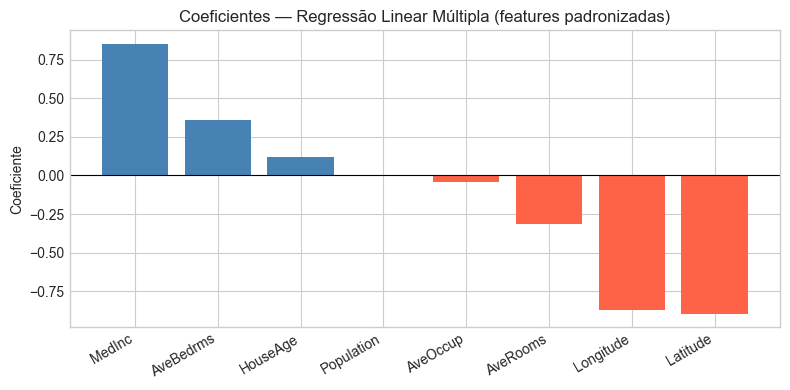

In [31]:
# ── Coeficientes do modelo (após padronização) ────────────────────────────
lr = pipe_A.named_steps['linearregression']
coef_df = pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": lr.coef_
}).sort_values("Coeficiente", ascending=False)

display(coef_df)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coeficiente']]
ax.bar(coef_df['Variável'], coef_df['Coeficiente'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regressão Linear Múltipla (features padronizadas)')
ax.set_ylabel('Coeficiente')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 📊 Interpretação — Regressão Linear Múltipla

- Coeficientes **positivos**: quando a variável aumenta, o valor previsto da casa também tende a subir.
- Coeficientes **negativos**: efeito inverso.
- Como as features estão **padronizadas** (média 0, desvio-padrão 1), os coeficientes são comparáveis entre si — os maiores em módulo são os mais influentes.

> **Limite deste modelo:** a relação capturada ainda é um *hiperplano*. Se os dados tiverem curvatura ou interações não-lineares, o modelo deixará isso de lado.

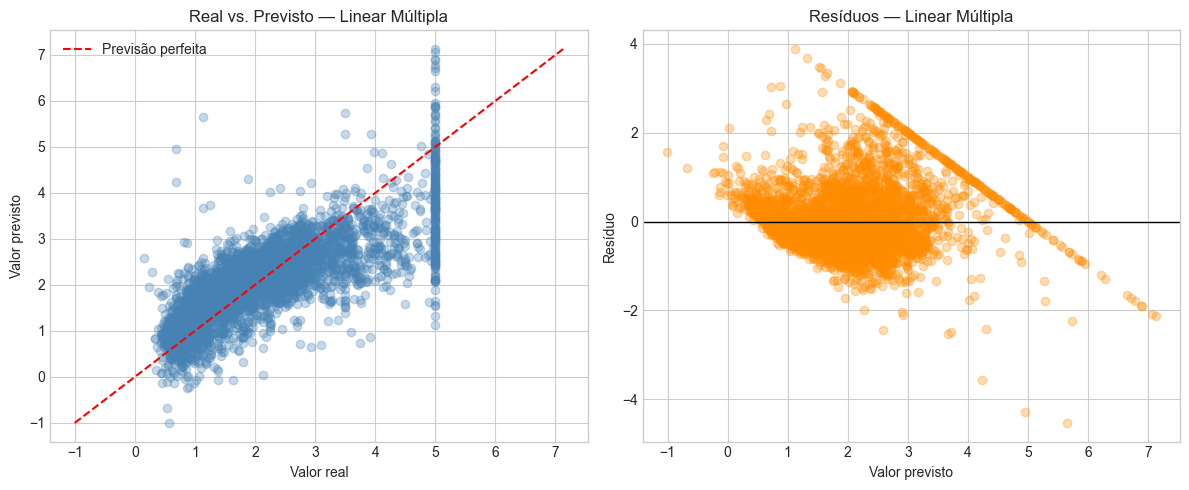

In [32]:
# ── Gráfico: valores reais vs. previstos ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Real vs Previsto
axes[0].scatter(y_val, y_val_pred_A, alpha=0.3, color='steelblue')
lims = [min(y_val.min(), y_val_pred_A.min()),
        max(y_val.max(), y_val_pred_A.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Previsão perfeita')
axes[0].set_xlabel('Valor real'); axes[0].set_ylabel('Valor previsto')
axes[0].set_title('Real vs. Previsto — Linear Múltipla')
axes[0].legend()

# Resíduos
residuos_A = y_val - y_val_pred_A
axes[1].scatter(y_val_pred_A, residuos_A, alpha=0.3, color='darkorange')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Valor previsto'); axes[1].set_ylabel('Resíduo')
axes[1].set_title('Resíduos — Linear Múltipla')

plt.tight_layout()
plt.show()

### Comentário sobre os gráficos

- **Real vs. Previsto:** pontos próximos da diagonal indicam boas previsões. Dispersão excessiva ou padrão em "leque" indica limitações do modelo.
- **Resíduos:** idealmente aleatórios em torno do zero. Padrões estruturados (curvas, funil) sugerem que o modelo deixou alguma informação não capturada — o que abre caminho para o próximo passo.

---

## 3. Passo 2 — O Poder da Não-Linearidade (Polynomial Features)

### Motivação

E se a relação entre as variáveis e o target **não for uma linha reta**?  
O `PolynomialFeatures` cria novas variáveis a partir das originais:

- **Termos quadráticos:** $x_1^2, x_2^2, \ldots$  
- **Interações:** $x_1 \cdot x_2, x_1 \cdot x_3, \ldots$

O modelo de regressão linear continua sendo **linear nos coeficientes** — mas agora as *features* são não-lineares, o que permite capturar curvaturas.

### Exemplo Simples: grau 2 em apenas `MedInc`

Antes de expandir todas as variáveis, vejamos o efeito visual em uma única feature.

[Modelo B — Polinomial grau 2 em MedInc | Validação]
  R²   = 0.4552  |  RMSE = 0.8433


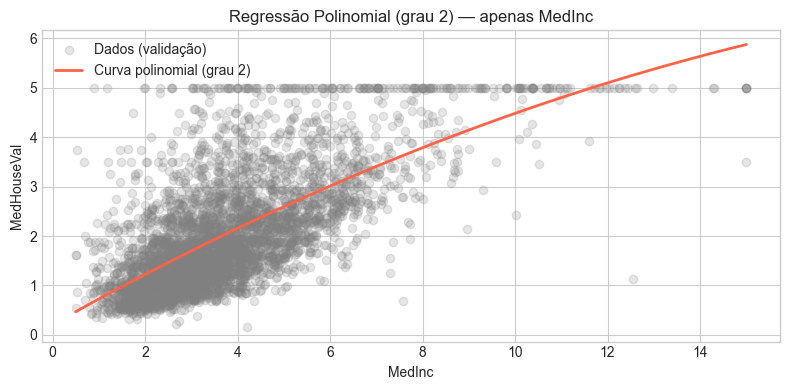

In [39]:
# ── Modelo B: Polinomial grau 2 apenas em MedInc ──────────────────────────
X_medinc_train = X_train[['MedInc']]
X_medinc_val   = X_val[['MedInc']]

pipe_B = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
pipe_B.fit(X_medinc_train, y_train)
y_val_pred_B = pipe_B.predict(X_medinc_val)

r2_B   = r2_score(y_val, y_val_pred_B)
rmse_B = np.sqrt(mean_squared_error(y_val, y_val_pred_B))
print(f"[Modelo B — Polinomial grau 2 em MedInc | Validação]")
print(f"  R²   = {r2_B:.4f}  |  RMSE = {rmse_B:.4f}")

# Visualização: curva polinomial vs. dados
xs = np.linspace(X['MedInc'].min(), X['MedInc'].max(), 300).reshape(-1, 1)
xs_df = pd.DataFrame(xs, columns=['MedInc'])
ys = pipe_B.predict(xs_df)

plt.figure(figsize=(8, 4))
plt.scatter(X_val['MedInc'], y_val, alpha=0.2, label='Dados (validação)', color='gray')
plt.plot(xs, ys, color='tomato', linewidth=2, label='Curva polinomial (grau 2)')
plt.xlabel('MedInc'); plt.ylabel('MedHouseVal')
plt.title('Regressão Polinomial (grau 2) — apenas MedInc')
plt.legend()
plt.tight_layout()
plt.show()

### A Explosão de Features: grau 2 em *todas* as variáveis

Quando aplicamos `PolynomialFeatures(degree=2)` a todas as **8 variáveis** originais, o número de features sobe para:

$$p = \frac{(n + d)!}{d! \cdot n!} - 1 = \frac{(8+2)!}{2! \cdot 8!} - 1 = 44 \text{ features}$$

Isso dá ao modelo **muito mais flexibilidade**, mas também aumenta o risco de **overfitting**.

In [40]:
# ── Demonstração de Overfitting: RMSE × grau do polinômio ─────────────────
degrees = [1, 2, 3, 4]  # grau 4 pode demorar; remova se necessário
historico = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_tr_p = poly.fit_transform(X_train)
    X_vl_p = poly.transform(X_val)

    scaler = StandardScaler()
    X_tr_p = scaler.fit_transform(X_tr_p)
    X_vl_p = scaler.transform(X_vl_p)

    lr = LinearRegression()
    lr.fit(X_tr_p, y_train)

    rmse_tr = np.sqrt(mean_squared_error(y_train, lr.predict(X_tr_p)))
    rmse_vl = np.sqrt(mean_squared_error(y_val,   lr.predict(X_vl_p)))
    r2_vl   = r2_score(y_val, lr.predict(X_vl_p))

    historico.append({'Grau': d, 'N° Features': X_tr_p.shape[1],
                      'RMSE Treino': rmse_tr, 'RMSE Validação': rmse_vl,
                      'R² Validação': r2_vl})
    print(f"Grau {d} | Features: {X_tr_p.shape[1]:4d} | RMSE treino: {rmse_tr:.3f} | RMSE val: {rmse_vl:.3f} | R²_val: {r2_vl:.3f}")

df_complex = pd.DataFrame(historico)
display(df_complex)

Grau 1 | Features:    8 | RMSE treino: 0.717 | RMSE val: 0.730 | R²_val: 0.592
Grau 2 | Features:   44 | RMSE treino: 0.645 | RMSE val: 0.700 | R²_val: 0.625
Grau 3 | Features:  164 | RMSE treino: 0.579 | RMSE val: 4.048 | R²_val: -11.552
Grau 4 | Features:  494 | RMSE treino: 0.523 | RMSE val: 56.375 | R²_val: -2433.734


,Grau,N° Features,RMSE Treino,RMSE Validação,R² Validação
0,1,8,0.7174,0.7298,0.5920
1,2,44,0.6450,0.6997,0.6249
2,3,164,0.5786,4.0478,-11.5522
3,4,494,0.5230,56.3751,-2433.7336


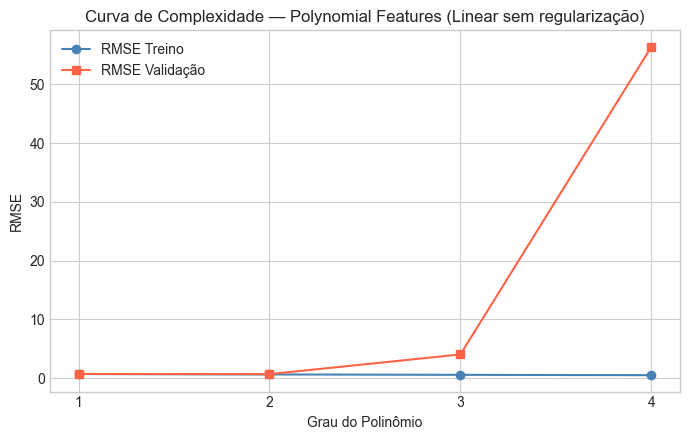

In [41]:
# ── Curva de Complexidade ──────────────────────────────────────────────────
plt.figure(figsize=(7, 4.5))
plt.plot(df_complex['Grau'], df_complex['RMSE Treino'],    marker='o', label='RMSE Treino',     color='steelblue')
plt.plot(df_complex['Grau'], df_complex['RMSE Validação'], marker='s', label='RMSE Validação',  color='tomato')
plt.xlabel('Grau do Polinômio')
plt.ylabel('RMSE')
plt.title('Curva de Complexidade — Polynomial Features (Linear sem regularização)')
plt.legend()
plt.xticks(degrees)
plt.tight_layout()
plt.show()

### 📊 Interpretação — Curva de Complexidade

| Grau | Comportamento |
|------|---------------|
| 1 | Modelo simples (hiperplano), treino ≈ validação → **boa generalização** |
| 2 | Melhora real; treino ligeiramente melhor que validação → **ponto ideal** |
| 3+ | RMSE treino cai, RMSE validação **dispara** → **overfitting** |

</br>

> **Conclusão:** o polinômio de grau 2 traz ganho real. Graus maiores fazem o modelo *decorar* os dados de treino sem generalizar.
>
> **Pergunta:** como explorar o polinômio de grau 2 sem cair no overfitting? **Regularização!**

---

## 4. Passo 3 — Dominando a Complexidade (Regularização)

A regularização adiciona uma **penalidade** à função de custo para evitar coeficientes muito grandes:

| Método | Penalidade | Efeito |
|--------|-----------|--------|
| **Ridge (L2)** | $\lambda \sum \theta_i^2$ | Encolhe coeficientes, mantém todos no modelo |
| **Lasso (L1)** | $\lambda \sum \theta_i$ | Zera alguns coeficientes (seleção de variáveis) |
| **Elastic Net** | $\lambda_1 \sum \theta_i + \lambda_2 \sum \theta_i^2$ | Combina Ridge + Lasso |

O parâmetro $\lambda$ (chamado `alpha` no scikit-learn) controla a intensidade da penalidade.

In [48]:
# ── Preparar features polinomiais de grau 2 (todas as variáveis) ──────────
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_p2 = poly2.fit_transform(X_train)
X_val_p2   = poly2.transform(X_val)
X_test_p2  = poly2.transform(X_test)

print(f"Features originais:   {X_train.shape[1]}")
print(f"Features grau 2:      {X_train_p2.shape[1]}")

Features originais:   8
Features grau 2:      44


In [49]:
# ── Treinar os 4 modelos com StandardScaler ────────────────────────────────
models_reg = {
    "Linear":      LinearRegression(),
    "Ridge":       Ridge(alpha=1.0),
    "Lasso":       Lasso(alpha=0.1, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

scaler_p2 = StandardScaler()
X_tr_s = scaler_p2.fit_transform(X_train_p2)
X_vl_s = scaler_p2.transform(X_val_p2)

results_reg = []
fitted_reg  = {}
preds_reg   = {}

for name, model in models_reg.items():
    model.fit(X_tr_s, y_train)
    y_pred = model.predict(X_vl_s)
    fitted_reg[name]  = model
    preds_reg[name]   = y_pred
    results_reg.append({
        "Modelo":  name,
        "R²":      r2_score(y_val, y_pred),
        "MAE":     mean_absolute_error(y_val, y_pred),
        "RMSE":    np.sqrt(mean_squared_error(y_val, y_pred)),
    })

df_reg = pd.DataFrame(results_reg).sort_values('RMSE').reset_index(drop=True)
display(df_reg)

,Modelo,R²,MAE,RMSE
0,Ridge,0.6510,0.4907,0.6750
1,Linear,0.6249,0.4742,0.6997
2,Elastic Net,0.5239,0.5883,0.7884
3,Lasso,0.4880,0.6172,0.8175


### 📊 Análise dos Resultados — Regularização com Polinômio de Grau 2

Observe como a regularização afeta o desempenho:

- **Ridge:** suaviza os coeficientes sem zerá-los; geralmente o melhor neste cenário.
- **Linear:** sem penalidade, pode ser instável com muitas features.
- **Lasso:** zera alguns coeficientes (seleção de variáveis), mas pode perder desempenho com `alpha` padrão.
- **Elastic Net:** equilíbrio entre Ridge e Lasso.

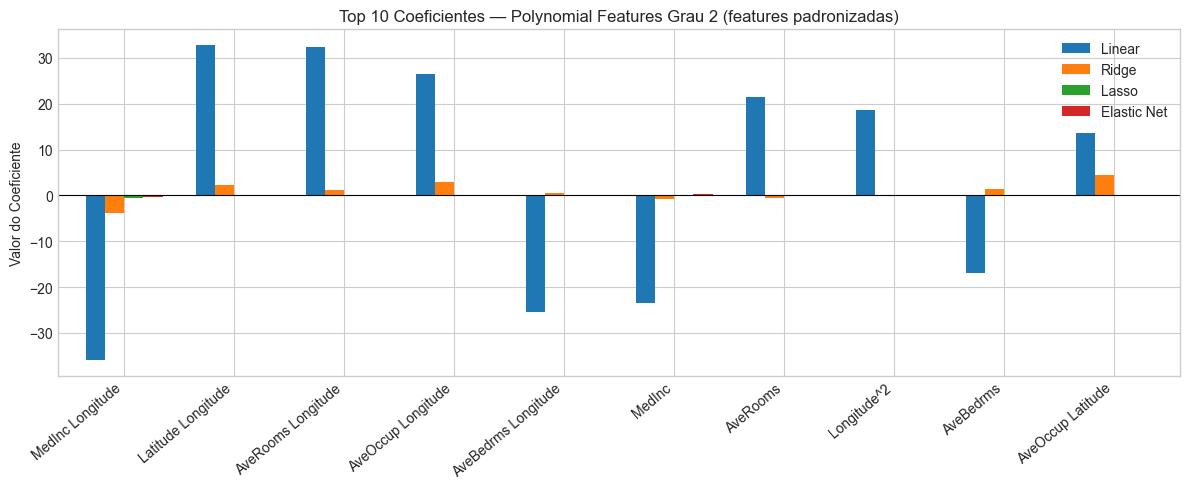

In [50]:
# ── Gráfico: Comparação de Coeficientes ───────────────────────────────────
feature_names = poly2.get_feature_names_out(X.columns)
coef_dict = {}
for name, model in fitted_reg.items():
    coef_dict[name] = model.coef_

coefs_df = pd.DataFrame(coef_dict, index=feature_names)

# Top 10 features por magnitude média
top10 = coefs_df.abs().mean(axis=1).sort_values(ascending=False).head(10).index

ax = coefs_df.loc[top10].plot(kind='bar', figsize=(12, 5), width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Top 10 Coeficientes — Polynomial Features Grau 2 (features padronizadas)')
ax.set_ylabel('Valor do Coeficiente')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

### 📉 Interpretação Comparativa dos Coeficientes

- **Linear:** coeficientes livres, podem ser muito grandes → instabilidade.
- **Ridge:** mesmas direções, mas **encolhidos** → mais estabilidade.
- **Lasso:** alguns coeficientes **zerados** → funciona como seleção automática de variáveis.
- **Elastic Net:** encolhe e zera ao mesmo tempo.

> A regularização não muda só as métricas — ela muda a *forma do modelo*, alterando como cada variável é utilizada.

In [51]:
# ── Quantos coeficientes o Lasso zerou? ───────────────────────────────────
lasso_zeros = (fitted_reg['Lasso'].coef_ == 0).sum()
lasso_total = len(fitted_reg['Lasso'].coef_)
print(f"Lasso: {lasso_zeros} de {lasso_total} coeficientes foram zerados ({lasso_zeros/lasso_total:.0%})")

Lasso: 41 de 44 coeficientes foram zerados (93%)


---

## 5. Passo 4 — O Veredito Final (Conjunto de Teste)

Após comparar todos os modelos na **validação**, selecionamos o **melhor** com base no menor RMSE.  
Agora, e **apenas agora**, avaliamos no conjunto de **teste** — que não foi tocado em nenhum momento anterior.

> Esta é a estimativa mais honesta da capacidade de **generalização** do modelo.

In [52]:
# ── Selecionar o modelo campeão pela validação ─────────────────────────────
best_name = df_reg.loc[0, 'Modelo']
best_model = fitted_reg[best_name]
print(f"Modelo campeão (validação): {best_name}")

# Avaliar no teste
X_te_s = scaler_p2.transform(X_test_p2)
y_test_pred = best_model.predict(X_te_s)

r2_test   = r2_score(y_test, y_test_pred)
mae_test  = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\n[{best_name} — Avaliação no TESTE]")
print(f"  R²   = {r2_test:.4f}")
print(f"  MAE  = {mae_test:.4f}")
print(f"  RMSE = {rmse_test:.4f}")

Modelo campeão (validação): Ridge

[Ridge — Avaliação no TESTE]
  R²   = 0.6346
  MAE  = 0.4943
  RMSE = 0.7078


In [53]:
# ── Tabela Resumo Final de todos os modelos ────────────────────────────────
resumo = pd.DataFrame([
    {"Modelo": "A) Linear Simples (MedInc — aula anterior)", "R² Val": 0.45, "RMSE Val": 0.71, "R² Teste": "—", "RMSE Teste": "—"},
    {"Modelo": "A) Linear Múltipla (todas as features)",
     "R² Val": round(r2_A, 4), "RMSE Val": round(rmse_A, 4), "R² Teste": "—", "RMSE Teste": "—"},
] + [
    {
        "Modelo":      f"{row['Modelo']} + Poly(2)",
        "R² Val":      row['R²'],
        "RMSE Val":    row['RMSE'],
        "R² Teste":    round(r2_test, 4)   if row['Modelo'] == best_name else "—",
        "RMSE Teste":  round(rmse_test, 4) if row['Modelo'] == best_name else "—",
    }
    for _, row in df_reg.iterrows()
])

display(resumo)

,Modelo,R² Val,RMSE Val,R² Teste,RMSE Teste
0,A) Linear Simples (MedInc — aula anterior),0.4500,0.7100,—,—
1,A) Linear Múltipla (todas as features),0.5920,0.7298,—,—
2,Ridge + Poly(2),0.6510,0.6750,0.6346,0.7078
3,Linear + Poly(2),0.6249,0.6997,—,—
4,Elastic Net + Poly(2),0.5239,0.7884,—,—
5,Lasso + Poly(2),0.4880,0.8175,—,—


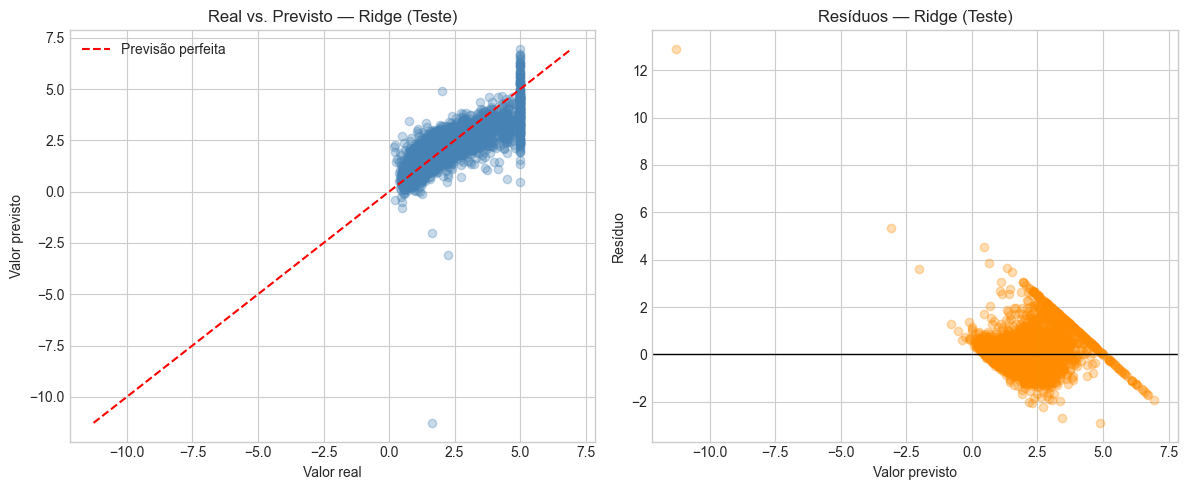

In [54]:
# ── Gráfico Real vs. Previsto — Modelo Campeão no Teste ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_test_pred, alpha=0.3, color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Previsão perfeita')
axes[0].set_xlabel('Valor real'); axes[0].set_ylabel('Valor previsto')
axes[0].set_title(f'Real vs. Previsto — {best_name} (Teste)')
axes[0].legend()

residuos_test = y_test - y_test_pred
axes[1].scatter(y_test_pred, residuos_test, alpha=0.3, color='darkorange')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Valor previsto'); axes[1].set_ylabel('Resíduo')
axes[1].set_title(f'Resíduos — {best_name} (Teste)')

plt.tight_layout()
plt.show()

### 📊 Diagnóstico Final

Analise:
1. O RMSE do **teste** ficou próximo ao da **validação**? → Bom sinal de generalização.
2. O modelo **não decorou** os dados de treino (sem overfitting severo)?
3. A regularização **ajudou** em comparação com o Linear simples?

---

## 6. Tarefas Práticas

As tarefas abaixo devem conter:
- **Código Python** com a implementação
- **Markdown** explicando e interpretando os resultados obtidos

---

### Tarefa A — Ajuste de Hiperparâmetros

Experimente diferentes valores de `alpha` para o modelo **Ridge** aplicado ao polinômio de grau 2.  
Sugestão: `alpha = [0.01, 0.1, 1.0, 10.0, 100.0]`.

- Treine um modelo Ridge para cada valor de `alpha` e registre o RMSE na validação.
- Plote um gráfico de `alpha` × `RMSE Validação`.
- Qual o melhor `alpha`? Compare com o obtido no Passo 3 (`alpha=1.0`).

In [ ]:
# Tarefa A — seu código aqui
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]



*Sua interpretação aqui...*

---

### Tarefa B — Super-Features do Lasso

O Lasso tem a propriedade de **zerar coeficientes irrelevantes**.

- Treine o Lasso no polinômio de grau 2 e identifique as **10 features de maior coeficiente** (em módulo).
- Apresente um gráfico de barras com essas features e seus coeficientes.
- Alguma dessas features faz sentido intuitivo? Por quê?

In [ ]:
# Tarefa B — seu código aqui


*Sua interpretação aqui...*

---

### Reflexão Crítica (Texto — sem código necessário)

Responda com suas palavras (mínimo 5 linhas):

> Na análise da curva de complexidade, o polinômio de grau 2 trouxe ganho real, mas o grau 3 gerou overfitting severo.  
> **Seria possível usar grau 3 com regularização (Ridge/Lasso) e ainda obter bons resultados?**
> Quais seriam os riscos e os desafios práticos?

*Sua resposta aqui...*